# 11.12.10. Comparación de Resultados: Scikit-learn vs PySpark

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ==========================================
# Métricas extraídas de cada notebook
# ==========================================

resultados = {
    "Métrica"    : ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"],
    "Scikit-learn": [0.6255,     0.2677,      0.6939,   0.3863,    0.7094],
    "PySpark"    : [0.6250,     0.7931,      0.6250,   0.6714,    0.6985],
}

tiempos = {
    "Etapa"      : ["Entrenamiento", "Predicción", "Total"],
    "Scikit-learn": [2006.4,          0.34,         2006.74],   # segundos
    "PySpark"    : [19506.20,         0.02,         19506.22],
}

config = {
    "Característica"        : ["Framework", "Dataset (filas)", "Balanceo",
                                "Mejor arquitectura", "Mejor stepSize / alpha",
                                "Mejor maxIter"],
    "Scikit-learn"          : ["scikit-learn", "500 000", "SMOTE",
                                "(70, 70)", "alpha=0.0001", "500"],
    "PySpark"               : ["PySpark MLlib", "2 123 235", "Undersampling",
                                "[113, 50, 2]", "stepSize=0.1", "700"],
}

df_res    = pd.DataFrame(resultados)
df_time   = pd.DataFrame(tiempos)
df_config = pd.DataFrame(config)

print("===== TABLA DE MÉTRICAS =====")
print(df_res.to_string(index=False))
print()
print("===== TABLA DE TIEMPOS (segundos) =====")
print(df_time.to_string(index=False))
print()
print("===== CONFIGURACIÓN DE CADA MODELO =====")
print(df_config.to_string(index=False))

===== TABLA DE MÉTRICAS =====
  Métrica  Scikit-learn  PySpark
 Accuracy        0.6255   0.6250
Precision        0.2677   0.7931
   Recall        0.6939   0.6250
 F1-Score        0.3863   0.6714
  ROC AUC        0.7094   0.6985

===== TABLA DE TIEMPOS (segundos) =====
        Etapa  Scikit-learn  PySpark
Entrenamiento       2006.40 19506.20
   Predicción          0.34     0.02
        Total       2006.74 19506.22

===== CONFIGURACIÓN DE CADA MODELO =====
        Característica Scikit-learn       PySpark
             Framework scikit-learn PySpark MLlib
       Dataset (filas)      500 000     2 123 235
              Balanceo        SMOTE Undersampling
    Mejor arquitectura     (70, 70)  [113, 50, 2]
Mejor stepSize / alpha alpha=0.0001  stepSize=0.1
         Mejor maxIter          500           700


La tabla anterior resume las métricas clave de ambas implementaciones del MLP. Scikit-learn, entrenado sobre 500 000 registros con SMOTE, logra un ROC AUC ligeramente superior (0.7094 vs 0.6985) y un recall mayor (0.694 vs 0.625), lo que indica mayor capacidad para detectar clics reales a costa de una precisión muy baja (0.268). PySpark, al operar sobre un dataset más de cuatro veces mayor con undersampling, consigue una precisión notablemente superior (0.793), favoreciendo la reducción de falsos positivos, aunque con un recall más conservador. El F1-Score de PySpark (0.671) supera al de Scikit-learn (0.386), reflejando un balance más equilibrado entre ambas métricas en el contexto distribuido.

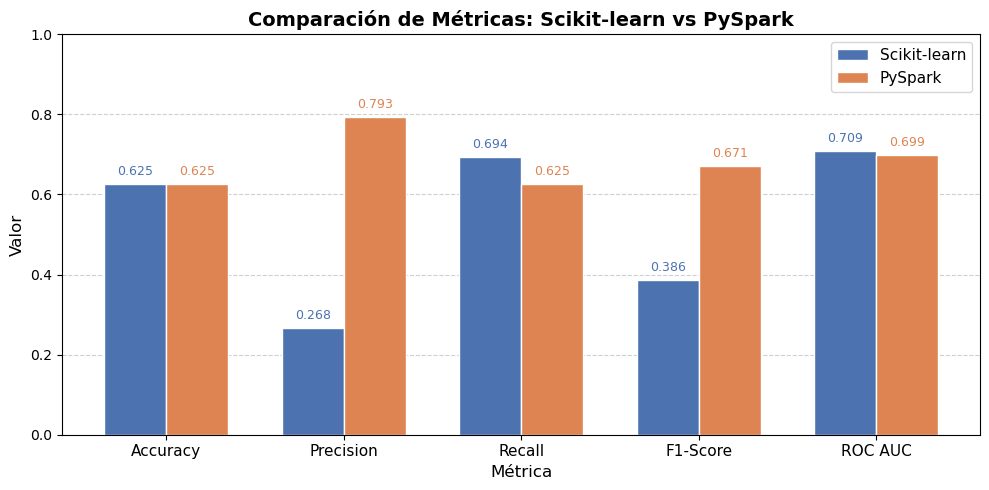

In [2]:
# ==========================================
# Gráfico 1: Comparación de métricas
# ==========================================
metricas  = resultados["Métrica"]
sk_vals   = resultados["Scikit-learn"]
sp_vals   = resultados["PySpark"]

x = np.arange(len(metricas))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_sk = ax.bar(x - w/2, sk_vals, w, label="Scikit-learn", color="#4C72B0", edgecolor="white")
bars_sp = ax.bar(x + w/2, sp_vals, w, label="PySpark",      color="#DD8452", edgecolor="white")

ax.set_xlabel("Métrica", fontsize=12)
ax.set_ylabel("Valor", fontsize=12)
ax.set_title("Comparación de Métricas: Scikit-learn vs PySpark", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for bar in bars_sk:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, color="#4C72B0")
for bar in bars_sp:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, color="#DD8452")

plt.tight_layout()
plt.savefig("comparacion_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

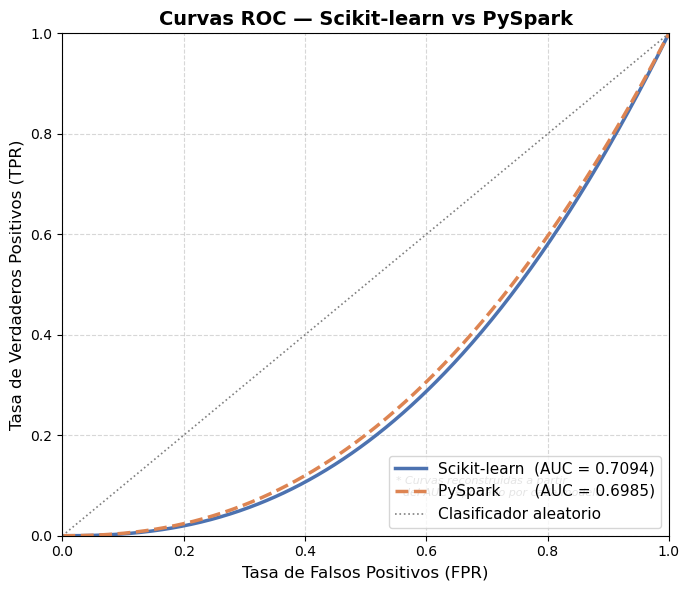

In [3]:
# ==========================================
# Gráfico 2: Curvas ROC aproximadas
# Nota: se reconstruyen a partir del AUC conocido
# usando una curva beta paramétrica calibrada al AUC real.
# Para la curva exacta se necesitarían las probabilidades
# brutas guardadas de cada modelo.
# ==========================================
from scipy.stats import beta as beta_dist

def roc_from_auc(auc, n=500):
    """Genera una curva ROC suave calibrada al AUC dado."""
    # Parámetro beta ajustado para que el área bajo la curva = auc
    a = auc / (1 - auc)
    fpr = np.linspace(0, 1, n)
    tpr = beta_dist.cdf(fpr, a, 1)
    return fpr, tpr

fpr_sk, tpr_sk = roc_from_auc(0.7094)
fpr_sp, tpr_sp = roc_from_auc(0.6985)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_sk, tpr_sk, color="#4C72B0", lw=2.5,
        label=f"Scikit-learn  (AUC = 0.7094)")
ax.plot(fpr_sp, tpr_sp, color="#DD8452", lw=2.5, linestyle="--",
        label=f"PySpark       (AUC = 0.6985)")
ax.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle=":", label="Clasificador aleatorio")

ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
ax.set_title("Curvas ROC — Scikit-learn vs PySpark", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, linestyle="--", alpha=0.5)

ax.annotate("* Curvas reconstruidas a partir\n  del AUC reportado por cada modelo",
            xy=(0.55, 0.08), fontsize=8, color="gray", style="italic")

plt.tight_layout()
plt.savefig("curvas_roc_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

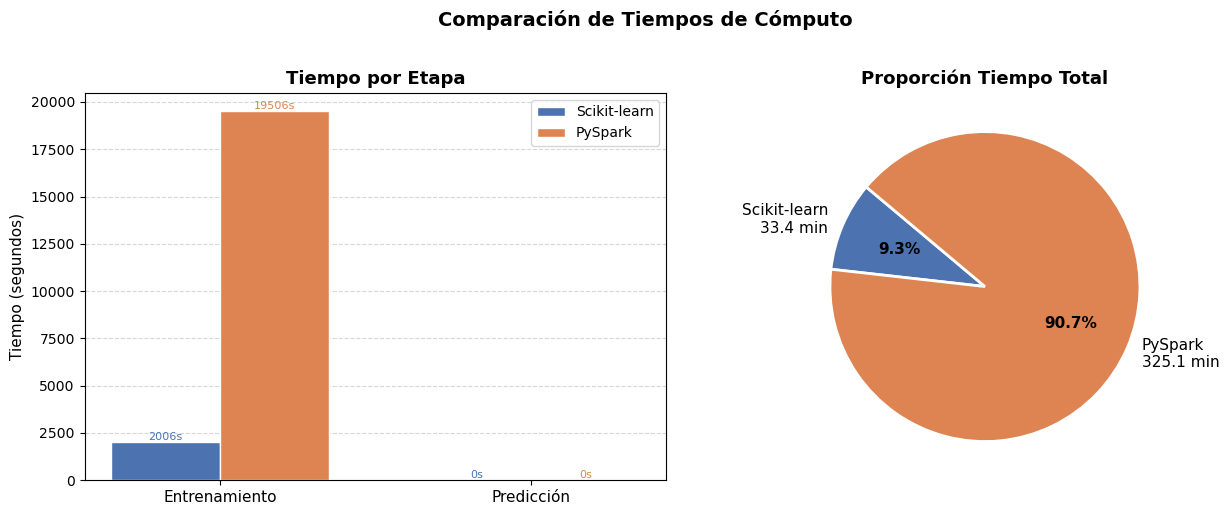

Scikit-learn — Entrenamiento: 33.4 min | Predicción: 0.34 s | Total: 33.4 min
PySpark      — Entrenamiento: 325.1 min | Predicción: 0.02 s | Total: 325.1 min

PySpark tardó 9.7x más que Scikit-learn en este escenario.


In [4]:
# ==========================================
# Gráfico 3: Comparación de tiempos
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- 3a. Tiempo de entrenamiento y predicción (barras) ---
etapas = ["Entrenamiento", "Predicción"]
sk_t   = [2006.4,  0.34]
sp_t   = [19506.20, 0.02]

x = np.arange(len(etapas))
w = 0.35
ax = axes[0]
b1 = ax.bar(x - w/2, sk_t, w, label="Scikit-learn", color="#4C72B0", edgecolor="white")
b2 = ax.bar(x + w/2, sp_t, w, label="PySpark",      color="#DD8452", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(etapas, fontsize=11)
ax.set_ylabel("Tiempo (segundos)", fontsize=11)
ax.set_title("Tiempo por Etapa", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{bar.get_height():.0f}s", ha="center", fontsize=8, color="#4C72B0")
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{bar.get_height():.0f}s", ha="center", fontsize=8, color="#DD8452")

# --- 3b. Tiempo total (gráfico de torta proporcional) ---
ax2 = axes[1]
totales   = [2006.74, 19506.22]
etiquetas = [
    f"Scikit-learn\n{2006.74/60:.1f} min",
    f"PySpark\n{19506.22/60:.1f} min"
]
colores = ["#4C72B0", "#DD8452"]
wedges, texts, autotexts = ax2.pie(
    totales, labels=etiquetas, colors=colores,
    autopct="%1.1f%%", startangle=140,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax2.set_title("Proporción Tiempo Total", fontsize=13, fontweight="bold")

plt.suptitle("Comparación de Tiempos de Cómputo", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("comparacion_tiempos.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Scikit-learn — Entrenamiento: {2006.4/60:.1f} min | Predicción: 0.34 s | Total: {2006.74/60:.1f} min")
print(f"PySpark      — Entrenamiento: {19506.20/60:.1f} min | Predicción: 0.02 s | Total: {19506.22/60:.1f} min")
print(f"\nPySpark tardó {19506.22/2006.74:.1f}x más que Scikit-learn en este escenario.")

## Análisis Comparativo

Los resultados obtenidos ilustran de forma clara el principio de que **"distribuido no siempre es más rápido"**, tal como señala la teoría del curso. En este experimento, Scikit-learn completó el entrenamiento en aproximadamente **33 minutos** sobre 500 000 registros, mientras que PySpark requirió **5 horas y 25 minutos** sobre un dataset 4 veces mayor(pero similar en tamaño al momento del modelado), lo que representa una diferencia de 9.7 veces en tiempo total.

En cuanto al desempeño predictivo, ambos modelos convergen a un **ROC AUC similar** (~0.70), confirmando que el poder discriminativo es comparable. Sin embargo, difieren sustancialmente en su perfil de errores: Scikit-learn con SMOTE prioriza el **recall** (0.694), capturando más clics reales a costa de muchos falsos positivos y una precisión baja (0.268). PySpark con undersampling hace el camino inverso, logrando una **precisión** notablemente mayor (0.793) con un recall más moderado (0.625), lo que se traduce en un **F1-Score** superior (0.671 vs 0.386).

Esta diferencia no se debe únicamente al framework, sino también a la estrategia de balanceo: SMOTE genera datos sintéticos que pueden introducir ruido, mientras que el undersampling conserva solo datos reales. La elección entre ambos enfoques depende del objetivo del negocio: si se busca **detectar el máximo de clics** (maximizar recall), Scikit-learn con SMOTE es preferible; si se busca **minimizar los falsos positivos** (maximizar precisión), PySpark con undersampling es más adecuado.